# TITLE: "MACHINE LEARNING WORK STATION"

**SUBTITLE**: "DATA CLEANING, CURATION, REMOVING REDUNDANT FEATURES, AND MACHINE LEARNING"

**AUTHORS**:

    - name: "Aya Abdine"
    - name: "Meriam Al Askri"
    - name: "Mcolisi Austine"
    - name: "Syed Arshan Nehad"
    - name: "Syed Tamjeed Ur Rahman"

# DATA CLEANING, INTERPRETATION, AND MACHINE LEARNING

WRITE A SHORT DESCRIPTION OF WHAT WILL BE DONE UNDER THIS SECTION. THIS CAN BE A GENERAL DESCRIPTION OF THE WORK STATION OR A DETAILED DESCRIPTION OF THE STEPS YOU WILL TAKE TO CLEAN, CURATE, AND ANALYZE THE DATA USING MACHINE LEARNING. YOU CAN ALSO USE THIS SPACE TO DESCRIBE THE STRUCTURE OF THIS WORK STATION AND HOW IT CONNECTS TO THE OTHER PAGES IN THE PROJECT.

# TOOLS AND LIBRARIES
*AN IMPORTANT NOTE: BEFORE RUNNING THE CODE IN THIS WORK STATION, MAKE SURE TO INSTALL THE NECESSARY LIBRARIES AND TOOLS FOR MACHINE LEARNING. THIS MAY INCLUDE SCIKIT-LEARN, TENSORFLOW, OR ANY OTHER LIBRARY YOU PLAN TO USE FOR YOUR ANALYSIS.*
*ALSO FIND THE ATTACHED VEDIO THAT I USED TO PLAN THIS WORKFLOW AND HOW THE WHOLE MACHINE LEARNING PROCESS CAN BE DONE*: https://youtu.be/29ZQ3TDGgRQ?si=j4zfUeVwksl3EYrh 

# Tools and Libraries

In [ ]:
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)

RANDOM_STATE = 42
DATA_PATH = 'Data/final_dataset.csv'

# Shared Helper Functions

These helper functions fix the biggest cleaning problems in the first . Votes such as `8.3K`, money values such as `$44,354,825`, durations such as `1h 44m`, and list-style text such as `['Drama', 'Musical']` are converted into machine-readable features.

In [ ]:
def parse_votes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(',', '')
    match = re.match(r'^([0-9]*\.?[0-9]+)\s*([KkMm]?)$', text)
    if not match:
        return pd.to_numeric(text, errors='coerce')
    number = float(match.group(1))
    suffix = match.group(2).lower()
    if suffix == 'k':
        number *= 1_000
    elif suffix == 'm':
        number *= 1_000_000
    return number


def parse_money(value):
    if pd.isna(value):
        return np.nan
    numbers = re.findall(r'[0-9]+(?:,[0-9]{3})*(?:\.[0-9]+)?|[0-9]+(?:\.[0-9]+)?', str(value))
    if not numbers:
        return np.nan
    return float(numbers[0].replace(',', ''))


def duration_to_minutes(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower()
    hours = re.search(r'(\d+)\s*h', text)
    minutes = re.search(r'(\d+)\s*m', text)
    total = 0
    if hours:
        total += int(hours.group(1)) * 60
    if minutes:
        total += int(minutes.group(1))
    return total if total > 0 else np.nan


def parse_list(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except Exception:
        pass
    return [item.strip().strip("'\"") for item in text.strip('[]').split(',') if item.strip().strip("'\"")]


def top_list_dummies(series, prefix, top_n=25):
    parsed = series.apply(parse_list)
    top_items = parsed.explode().value_counts().head(top_n).index.tolist()
    top_set = set(top_items)
    filtered = parsed.apply(lambda values: [value for value in values if value in top_set])
    mlb = MultiLabelBinarizer(classes=top_items)
    encoded = mlb.fit_transform(filtered)
    clean_columns = [f"{prefix}_{re.sub(r'[^A-Za-z0-9]+', '_', item).strip('_')[:45]}" for item in top_items]
    return pd.DataFrame(encoded, columns=clean_columns, index=series.index), top_items


def fill_numeric_medians(frame):
    clean = frame.copy()
    for column in clean.columns:
        clean[column] = pd.to_numeric(clean[column], errors='coerce')
        clean[column] = clean[column].fillna(clean[column].median())
    return clean


def regression_table(models, X_train, X_test, y_train, y_test, clip_rating=False, inverse_log=False):
    rows = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        if clip_rating:
            pred = np.clip(pred, 0, 10)
        rows.append({
            'Model': name,
            'MAE': mean_absolute_error(y_test, pred),
            'RMSE': mean_squared_error(y_test, pred) ** 0.5,
            'R2 Score': r2_score(y_test, pred),
        })
        if inverse_log:
            rows[-1]['MAE Original Scale'] = mean_absolute_error(np.expm1(y_test), np.expm1(pred))
        fitted[name] = model
    results = pd.DataFrame(rows).sort_values('R2 Score', ascending=False).reset_index(drop=True)
    return results, fitted


def classification_table(models, X_train, X_test, y_train, y_test):
    rows = []
    fitted = {}
    predictions = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        proba = model.predict_proba(X_test)[:, 1]
        rows.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1 Score': f1_score(y_test, pred, zero_division=0),
            'ROC AUC': roc_auc_score(y_test, proba),
        })
        fitted[name] = model
        predictions[name] = pred
    results = pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)
    return results, fitted, predictions

# Shared Plotting Helpers

These plotting helpers keep the result sections clean and consistent. They create compact visual diagnostics for model comparison, prediction quality, residual behavior, and feature importance.

In [ ]:

def plot_regression_results(results, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ['MAE', 'RMSE', 'R2 Score']
    colors = ['#3A86FF', '#FF6B6B', '#2A9D8F']
    for ax, metric, color in zip(axes, metrics, colors):
        ordered = results.sort_values(metric, ascending=(metric != 'R2 Score'))
        ax.barh(ordered['Model'], ordered[metric], color=color)
        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.invert_yaxis()
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_true, y_pred, title, xlabel='Actual', ylabel='Predicted'):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.35, s=18, color='#3A86FF')
    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))
    ax.plot([low, high], [low, high], color='#E63946', linewidth=2, label='Perfect prediction')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(y_pred, residuals, alpha=0.35, s=18, color='#8338EC')
    axes[0].axhline(0, color='#E63946', linewidth=2)
    axes[0].set_title('Residuals vs predictions')
    axes[0].set_xlabel('Predicted values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(alpha=0.25)
    axes[1].hist(residuals, bins=35, color='#2A9D8F', edgecolor='white')
    axes[1].axvline(0, color='#E63946', linewidth=2)
    axes[1].set_title('Residual distribution')
    axes[1].set_xlabel('Actual - predicted')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title, top_n=15):
    estimator = model
    if hasattr(model, 'named_steps'):
        estimator = list(model.named_steps.values())[-1]
    if not hasattr(estimator, 'feature_importances_'):
        print('This model does not expose feature_importances_.')
        return
    importances = pd.Series(estimator.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importances.index[::-1], importances.values[::-1], color='#FFB703')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


def plot_classification_results(results, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric, color in zip(axes, ['Accuracy', 'F1 Score', 'ROC AUC'], ['#3A86FF', '#2A9D8F', '#FF6B6B']):
        ordered = results.sort_values(metric, ascending=False)
        ax.barh(ordered['Model'], ordered[metric], color=color)
        ax.set_xlim(0, 1)
        ax.set_title(metric)
        ax.invert_yaxis()
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Load the Dataset Once

In [ ]:
df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', df.shape)
df.head(3)

## Q1: Can movie success, measured by rating, be predicted using features such as genre, duration, budget, and release date?

### Data Cleaning

In [ ]:
q1 = df[['rating', 'votes', 'duration', 'budget', 'release_date', 'genres', 'stars', 'directors', 'mpa']].copy()

q1['rating'] = pd.to_numeric(q1['rating'], errors='coerce')
q1['votes_num'] = q1['votes'].apply(parse_votes)
q1['log_votes'] = np.log1p(q1['votes_num'])
q1['duration_min'] = q1['duration'].apply(duration_to_minutes)
q1['budget_num'] = q1['budget'].apply(parse_money)
q1['log_budget'] = np.log1p(q1['budget_num'])

release_date = pd.to_datetime(q1['release_date'], errors='coerce')
q1['release_year'] = release_date.dt.year
q1['release_month'] = release_date.dt.month
q1['movie_age'] = 2026 - q1['release_year']

q1['star_count'] = q1['stars'].apply(lambda value: len(parse_list(value)))
q1['director_count'] = q1['directors'].apply(lambda value: len(parse_list(value)))
q1['mpa'] = q1['mpa'].fillna('Unknown').astype(str).str.strip()

q1 = q1.dropna(subset=['rating']).reset_index(drop=True)
print('Q1 cleaned shape:', q1.shape)
q1[['rating', 'votes_num', 'duration_min', 'budget_num', 'release_year', 'release_month']].describe()

The Q1 cleaning step keeps the original target, `rating`, but improves the predictors. Votes with `K` or `M` suffixes are converted correctly, budget symbols and commas are removed, duration is converted to minutes, and release date is transformed into year, month, and movie age. I also add simple crew-size signals from the stars and directors lists.

### Data Curation

In [ ]:
y_Q1 = q1['rating']
q1_numeric_features = fill_numeric_medians(q1[[
    'log_votes', 'duration_min', 'log_budget', 'release_year', 'release_month',
    'movie_age', 'star_count', 'director_count'
]])

print('Q1 target shape:', y_Q1.shape)
print('Q1 numeric feature shape:', q1_numeric_features.shape)

The target variable is the movie rating. The numeric predictors include popularity strength (`log_votes`), runtime, budget, release timing, movie age, and simple cast/director count features. The log transformations reduce the extreme skew caused by blockbuster-size values.

### Removing Redundant Features

In [ ]:
q1_genre_dummies, q1_top_genres = top_list_dummies(q1['genres'], 'genre', top_n=30)
q1_mpa_dummies = pd.get_dummies(q1['mpa'], prefix='mpa')

X_Q1_reduced = pd.concat([q1_numeric_features, q1_genre_dummies, q1_mpa_dummies], axis=1).astype(float)

print('Top Q1 genres kept:', q1_top_genres[:10])
print('Q1 reduced feature shape:', X_Q1_reduced.shape)

Instead of creating messy genre columns from the raw string, this parses the list format correctly and keeps the 30 most common genres. This reduces sparse noise while preserving the genre information most likely to help the model.

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
X_final_Q1 = X_Q1_reduced.copy()
y_final_Q1 = y_Q1.copy()

print('Final Q1 X shape:', X_final_Q1.shape)
print('Final Q1 y shape:', y_final_Q1.shape)

The final Q1 input matrix combines cleaned numeric variables, selected genre indicators, and MPA rating indicators. The output remains the continuous movie rating, so this is a regression task.

### Data Splitting (Train-Test set and test set)

In [ ]:
X_train_Q1, X_test_Q1, y_train_Q1, y_test_Q1 = train_test_split(
    X_final_Q1,
    y_final_Q1,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print('Q1 X_train:', X_train_Q1.shape)
print('Q1 X_test:', X_test_Q1.shape)
print('Q1 y_train:', y_train_Q1.shape)
print('Q1 y_test:', y_test_Q1.shape)

An 80/20 train-test split is used so the model is evaluated on unseen movies. The fixed random state makes the split reproducible.

#### Save splits in form of CSV files

In [ ]:
train_Q1 = X_train_Q1.copy()
train_Q1['rating'] = y_train_Q1.values

test_Q1 = X_test_Q1.copy()
test_Q1['rating'] = y_test_Q1.values

train_Q1.to_csv('Data/train_Q1.csv', index=False)
test_Q1.to_csv('Data/test_Q1.csv', index=False)
print('Saved Data/train_Q1.csv and Data/test_Q1.csv')

The split files are saved with `_` prefixes so the original train-test files are not overwritten.

### Selecting and training machine learning models

In [ ]:
q1_models = {
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Random Forest': RandomForestRegressor(
        n_estimators=60,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=60,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
}

q1_results, q1_fitted_models = regression_table(
    q1_models,
    X_train_Q1,
    X_test_Q1,
    y_train_Q1,
    y_test_Q1,
    clip_rating=True,
)
q1_results

The model comparison uses Ridge Regression as a clean baseline and two ensemble models to capture nonlinear relationships. Extra Trees and Random Forest usually perform better here because rating is affected by interactions between popularity, release period, genre, and runtime rather than one simple straight-line pattern.

### Evaluate model performance

The Q1 regression model is evaluated with three core formulas:

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

For ratings, MAE is especially intuitive because it tells us the average prediction error in rating points.

In [ ]:
q1_best_name = q1_results.loc[0, 'Model']
q1_best_model = q1_fitted_models[q1_best_name]
q1_pred = np.clip(q1_best_model.predict(X_test_Q1), 0, 10)

print('Best Q1 model:', q1_best_name)
print('MAE:', mean_absolute_error(y_test_Q1, q1_pred))
print('RMSE:', mean_squared_error(y_test_Q1, q1_pred) ** 0.5)
print('R2 Score:', r2_score(y_test_Q1, q1_pred))

pd.DataFrame({'Actual rating': y_test_Q1.values[:10], 'Predicted rating': q1_pred[:10]})

In [ ]:

plot_regression_results(q1_results, 'Q1 Model Comparison: Rating Prediction')
plot_actual_vs_predicted(
    y_test_Q1,
    q1_pred,
    'Q1 Actual vs Predicted Ratings',
    xlabel='Actual IMDb rating',
    ylabel='Predicted IMDb rating',
)
plot_residuals(y_test_Q1, q1_pred, 'Q1 Rating Error Diagnostics')
plot_feature_importance(q1_best_model, X_train_Q1.columns, 'Q1 Top Feature Importances')


The Q1 graphs show the full result story: the model-comparison chart identifies the strongest algorithm, the diagonal scatter plot shows how close predictions are to perfect predictions, the residual plots reveal where the model still makes mistakes, and the feature-importance chart explains which variables drive the best model.

Q1 is now much stronger than the simple linear-regression because the model receives cleaner numerical values and correctly parsed genre information. The best model should be judged mainly by MAE and R2: lower MAE means predicted ratings are closer to the real ratings, while higher R2 means the selected features explain more of the rating variation.

## Q2: Can box office revenue be predicted using movie characteristics such as genre, stars, directors, and budget?

### Data Cleaning

In [ ]:
q2 = df[['gross_worldwide', 'budget', 'duration', 'release_date', 'genres', 'stars', 'directors', 'mpa', 'votes']].copy()

q2['gross_worldwide_num'] = q2['gross_worldwide'].apply(parse_money)
q2['log_gross_worldwide'] = np.log1p(q2['gross_worldwide_num'])
q2['budget_num'] = q2['budget'].apply(parse_money)
q2['log_budget'] = np.log1p(q2['budget_num'])
q2['duration_min'] = q2['duration'].apply(duration_to_minutes)
q2['votes_num'] = q2['votes'].apply(parse_votes)
q2['log_votes'] = np.log1p(q2['votes_num'])

release_date = pd.to_datetime(q2['release_date'], errors='coerce')
q2['release_year'] = release_date.dt.year
q2['release_month'] = release_date.dt.month
q2['movie_age'] = 2026 - q2['release_year']

q2['star_count'] = q2['stars'].apply(lambda value: len(parse_list(value)))
q2['director_count'] = q2['directors'].apply(lambda value: len(parse_list(value)))
q2['mpa'] = q2['mpa'].fillna('Unknown').astype(str).str.strip()

q2 = q2.dropna(subset=['gross_worldwide_num']).reset_index(drop=True)
print('Q2 cleaned shape:', q2.shape)
q2[['gross_worldwide_num', 'budget_num', 'duration_min', 'votes_num']].describe()

Revenue has very large outliers, so the target is transformed with `log1p`. This makes the model learn relative differences between small, medium, and blockbuster movies instead of being dominated by a few extreme box-office hits. Budget, runtime, release timing, votes, star count, director count, genre, star names, and director names are cleaned for modeling.

### Data Curation

In [ ]:
y_Q2 = q2['log_gross_worldwide']
q2_numeric_features = fill_numeric_medians(q2[[
    'log_budget', 'duration_min', 'release_year', 'release_month', 'movie_age',
    'star_count', 'director_count', 'log_votes'
]])

print('Q2 target shape:', y_Q2.shape)
print('Q2 numeric feature shape:', q2_numeric_features.shape)

The Q2 target is log-transformed worldwide gross revenue. The predictors include budget, release timing, runtime, audience-vote volume, and compact cast/director count variables. The vote-volume feature makes this an outcome-aware revenue model; for a strictly pre-release forecast, remove `log_votes`.

### Removing Redundant Features

In [ ]:
q2_genre_dummies, q2_top_genres = top_list_dummies(q2['genres'], 'genre', top_n=30)
q2_star_dummies, q2_top_stars = top_list_dummies(q2['stars'], 'star', top_n=30)
q2_director_dummies, q2_top_directors = top_list_dummies(q2['directors'], 'director', top_n=30)
q2_mpa_dummies = pd.get_dummies(q2['mpa'], prefix='mpa')

X_Q2_reduced = pd.concat([
    q2_numeric_features,
    q2_genre_dummies,
    q2_star_dummies,
    q2_director_dummies,
    q2_mpa_dummies,
], axis=1).astype(float)

print('Top Q2 genres kept:', q2_top_genres[:10])
print('Top Q2 stars kept:', q2_top_stars[:5])
print('Top Q2 directors kept:', q2_top_directors[:5])
print('Q2 reduced feature shape:', X_Q2_reduced.shape)

The original Q2 removed stars and directors because the raw columns were high-cardinality. In this version keeps them in a controlled way by selecting only the most frequent stars and directors, plus count features. That gives the model richer information while avoiding thousands of sparse columns.

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
X_final_Q2 = X_Q2_reduced.copy()
y_final_Q2 = y_Q2.copy()

print('Final Q2 X shape:', X_final_Q2.shape)
print('Final Q2 y shape:', y_final_Q2.shape)

The final Q2 feature matrix is fully numeric and compact. The output variable is log worldwide gross, so regression metrics are reported on the log scale, with an additional MAE converted back to the original revenue scale.

### Data Splitting (Train-Test set and test set)

In [ ]:
X_train_Q2, X_test_Q2, y_train_Q2, y_test_Q2 = train_test_split(
    X_final_Q2,
    y_final_Q2,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print('Q2 X_train:', X_train_Q2.shape)
print('Q2 X_test:', X_test_Q2.shape)
print('Q2 y_train:', y_train_Q2.shape)
print('Q2 y_test:', y_test_Q2.shape)

An 80/20 split is used for Q2 so revenue prediction is evaluated on unseen movies.

#### Save splits in form of CSV files

In [ ]:
train_Q2 = X_train_Q2.copy()
train_Q2['log_gross_worldwide'] = y_train_Q2.values

test_Q2 = X_test_Q2.copy()
test_Q2['log_gross_worldwide'] = y_test_Q2.values

train_Q2.to_csv('Data/train_Q2.csv', index=False)
test_Q2.to_csv('Data/test_Q2.csv', index=False)
print('Saved Data/train_Q2.csv and Data/test_Q2.csv')

The Q2 train-test files are saved for the revenue prediction task.

### Selecting and training machine learning models

In [ ]:
q2_models = {
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=10)),
    'Random Forest': RandomForestRegressor(
        n_estimators=60,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=60,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
}

q2_results, q2_fitted_models = regression_table(
    q2_models,
    X_train_Q2,
    X_test_Q2,
    y_train_Q2,
    y_test_Q2,
    inverse_log=True,
)
q2_results

Q2 uses the same baseline-versus-ensemble logic as Q1. The target is log revenue because box office numbers are extremely skewed. This usually creates a much more stable and impressive revenue model than training directly on raw dollars.

### Evaluate model performance

Q2 uses the same regression metrics, but the target is transformed because revenue is extremely skewed:

$$y_{log} = \log(1 + y)$$

Predictions are converted back to dollars with:

$$\hat{y} = e^{\hat{y}_{log}} - 1$$

This makes the model focus on proportional revenue patterns instead of allowing a few huge blockbusters to dominate the loss function.

In [ ]:
q2_best_name = q2_results.loc[0, 'Model']
q2_best_model = q2_fitted_models[q2_best_name]
q2_pred_log = q2_best_model.predict(X_test_Q2)
q2_pred_revenue = np.expm1(q2_pred_log)
q2_actual_revenue = np.expm1(y_test_Q2)

print('Best Q2 model:', q2_best_name)
print('MAE on log revenue:', mean_absolute_error(y_test_Q2, q2_pred_log))
print('RMSE on log revenue:', mean_squared_error(y_test_Q2, q2_pred_log) ** 0.5)
print('R2 Score on log revenue:', r2_score(y_test_Q2, q2_pred_log))
print('MAE on original revenue scale:', mean_absolute_error(q2_actual_revenue, q2_pred_revenue))

pd.DataFrame({
    'Actual revenue': q2_actual_revenue.values[:10],
    'Predicted revenue': q2_pred_revenue[:10],
})

In [ ]:

plot_regression_results(q2_results, 'Q2 Model Comparison: Log Revenue Prediction')
plot_actual_vs_predicted(
    y_test_Q2,
    q2_pred_log,
    'Q2 Actual vs Predicted Log Revenue',
    xlabel='Actual log worldwide gross',
    ylabel='Predicted log worldwide gross',
)
plot_residuals(y_test_Q2, q2_pred_log, 'Q2 Log Revenue Error Diagnostics')
plot_feature_importance(q2_best_model, X_train_Q2.columns, 'Q2 Top Feature Importances')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(q2_actual_revenue, q2_pred_revenue, alpha=0.35, s=18, color='#3A86FF')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Q2 Revenue Predictions on Original Dollar Scale', fontweight='bold')
ax.set_xlabel('Actual worldwide gross')
ax.set_ylabel('Predicted worldwide gross')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


The Q2 visual diagnostics are designed for a stronger revenue story. The log-scale prediction chart shows whether the model captures the overall revenue level, while the dollar-scale chart makes blockbuster errors visible without flattening smaller films.

The best Q2 model should be interpreted primarily on the log scale because the original revenue scale contains extreme outliers. A strong R2 on log revenue means the model is successfully learning the broad box-office level of a movie, while the original-scale MAE shows how expensive errors can still be for blockbuster films.

## Q3: Can we predict whether a movie will receive a high rating based on its features?

### Data Cleaning

In [ ]:
q3 = df[['rating', 'votes', 'duration', 'budget', 'release_date', 'genres', 'stars', 'directors', 'mpa']].copy()

q3['rating'] = pd.to_numeric(q3['rating'], errors='coerce')
q3 = q3.dropna(subset=['rating']).reset_index(drop=True)
q3['high_rating'] = (q3['rating'] >= 7).astype(int)

q3['votes_num'] = q3['votes'].apply(parse_votes)
q3['log_votes'] = np.log1p(q3['votes_num'])
q3['duration_min'] = q3['duration'].apply(duration_to_minutes)
q3['budget_num'] = q3['budget'].apply(parse_money)
q3['log_budget'] = np.log1p(q3['budget_num'])

release_date = pd.to_datetime(q3['release_date'], errors='coerce')
q3['release_year'] = release_date.dt.year
q3['release_month'] = release_date.dt.month
q3['movie_age'] = 2026 - q3['release_year']

q3['star_count'] = q3['stars'].apply(lambda value: len(parse_list(value)))
q3['director_count'] = q3['directors'].apply(lambda value: len(parse_list(value)))
q3['mpa'] = q3['mpa'].fillna('Unknown').astype(str).str.strip()

print('Q3 cleaned shape:', q3.shape)
print(q3['high_rating'].value_counts(normalize=True).rename('class_share'))

For Q3, the continuous rating is converted into a binary classification target. Movies with a rating of 7.0 or higher are labeled as high-rated. The same improved parsers from Q1 are reused so the classifier receives clean, consistent predictors.

### Data Curation

In [ ]:
y_Q3 = q3['high_rating']
q3_numeric_features = fill_numeric_medians(q3[[
    'log_votes', 'duration_min', 'log_budget', 'release_year', 'release_month',
    'movie_age', 'star_count', 'director_count'
]])

print('Q3 target shape:', y_Q3.shape)
print('Q3 numeric feature shape:', q3_numeric_features.shape)

The target variable is `high_rating`, and the predictors are the cleaned numeric movie features. This turns the problem into a classification task rather than a regression task.

### Removing Redundant Features

In [ ]:
q3_genre_dummies, q3_top_genres = top_list_dummies(q3['genres'], 'genre', top_n=30)
q3_mpa_dummies = pd.get_dummies(q3['mpa'], prefix='mpa')

X_Q3_reduced = pd.concat([q3_numeric_features, q3_genre_dummies, q3_mpa_dummies], axis=1).astype(float)

print('Top Q3 genres kept:', q3_top_genres[:10])
print('Q3 reduced feature shape:', X_Q3_reduced.shape)

As in Q1, genre features are parsed properly and reduced to the most frequent genres. This avoids noisy columns such as partially parsed strings and keeps the classification feature space manageable.

### Data Transformation: Creating X Input and Y Output Variables

In [ ]:
X_final_Q3 = X_Q3_reduced.copy()
y_final_Q3 = y_Q3.copy()

print('Final Q3 X shape:', X_final_Q3.shape)
print('Final Q3 y shape:', y_final_Q3.shape)

The final Q3 input matrix is numeric and ready for classification. The output is binary: `1` means high-rated, and `0` means not high-rated.

### Data Splitting (Train-Test set and test set)

In [ ]:
X_train_Q3, X_test_Q3, y_train_Q3, y_test_Q3 = train_test_split(
    X_final_Q3,
    y_final_Q3,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_final_Q3,
)

print('Q3 X_train:', X_train_Q3.shape)
print('Q3 X_test:', X_test_Q3.shape)
print('Q3 y_train:', y_train_Q3.shape)
print('Q3 y_test:', y_test_Q3.shape)
print('Training class share:', y_train_Q3.mean())
print('Testing class share:', y_test_Q3.mean())

The Q3 split is stratified. This keeps the percentage of high-rated movies similar in both the training and test sets, which is important for classification.

#### Save splits in form of CSV files

In [ ]:
train_Q3 = X_train_Q3.copy()
train_Q3['high_rating'] = y_train_Q3.values

test_Q3 = X_test_Q3.copy()
test_Q3['high_rating'] = y_test_Q3.values

train_Q3.to_csv('Data/train_Q3.csv', index=False)
test_Q3.to_csv('Data/test_Q3.csv', index=False)
print('Saved Data/train_Q3.csv and Data/test_Q3.csv')

The Q3 split files are saved for the high-rating classification task.

### Selecting and training machine learning models

In [ ]:
q3_models = {
    'Logistic Regression': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=60,
        max_depth=18,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=60,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
}

q3_results, q3_fitted_models, q3_predictions = classification_table(
    q3_models,
    X_train_Q3,
    X_test_Q3,
    y_train_Q3,
    y_test_Q3,
)
q3_results

The Q3 model comparison includes a balanced Logistic Regression baseline and two ensemble classifiers. Because this is a classification problem, F1 score and ROC AUC are more informative than accuracy alone.

### Evaluate model performance

Q3 is a classification task, so the important formulas change:

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

Accuracy tells us the total share of correct predictions, while F1 is better when we care specifically about identifying high-rated movies.

In [ ]:
q3_best_name = q3_results.loc[0, 'Model']
q3_best_pred = q3_predictions[q3_best_name]

print('Best Q3 model:', q3_best_name)
print('Confusion matrix:')
print(confusion_matrix(y_test_Q3, q3_best_pred))
print('\nClassification report:')
print(classification_report(y_test_Q3, q3_best_pred, zero_division=0))

In [ ]:

plot_classification_results(q3_results, 'Q3 Model Comparison: High-Rating Classification')

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_Q3,
    q3_best_pred,
    display_labels=['Not high-rated', 'High-rated'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title(f'Q3 Confusion Matrix: {q3_best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(q3_fitted_models[q3_best_name], X_test_Q3, y_test_Q3, ax=ax, color='#E63946')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title(f'Q3 ROC Curve: {q3_best_name}', fontweight='bold')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plot_feature_importance(q3_fitted_models[q3_best_name], X_train_Q3.columns, 'Q3 Top Feature Importances')


The Q3 visuals make the classification result easier to defend. The metric bars compare models, the confusion matrix shows the exact types of mistakes, the ROC curve shows ranking power across thresholds, and the feature-importance chart explains what the best classifier relied on.

The final Q3 evaluation reports the confusion matrix and classification report for the best model. The goal is not only to get high accuracy, but also to correctly identify high-rated movies, which is why F1 score, precision, recall, and ROC AUC are included.

## Q4: Can the number of audience votes be predicted using movie popularity factors such as stars, release date, and budget?

### Data Cleaning

In [2]:
import pandas as pd
import os

# List files in current directory
print(os.listdir())

['.git', '.gitignore', '.quarto', '.venv', 'conclusion.qmd', 'dashboard.qmd', 'final_dataset.csv', 'index.qmd', 'INSTRUCTIONS.md', 'MAIN WORKING STATION.qmd', 'name.basics.tsv', 'qmd_to_ipynb.py', 'README.md', 'sec1.qmd', 'sec2.ipynb', 'title.akas.tsv', 'title.basics.tsv', 'title.crew.tsv', 'title.episode.tsv', 'title.principals.tsv', 'title.ratings.tsv', 'WORK STATION FOR DESCRIPTIVE ANALYSIS.qmd', 'WORK STATION FOR MACHINE LEARNING.ipynb', 'WORK STATION FOR MACHINE LEARNING.qmd', 'WORKPLAN.md', '_quarto.yml', '_site']


Loading movies from tittle.basics.tsv

In [5]:
import pandas as pd

# Load the CSV and the Ratings
df_csv = pd.read_csv('final_dataset.csv')
df_ratings = pd.read_csv('title.ratings.tsv', sep='\t')

# Rename 'id' to 'tconst' in the CSV so they match exactly for the merge
df_csv = df_csv.rename(columns={'id': 'tconst'})

# Perform the Left Join
# We merge on 'tconst'
df_merged = pd.merge(df_csv, df_ratings, on='tconst', how='left')

# Let's see how much we recovered
print("--- After Merging ---")
print(f"Total rows: {len(df_merged)}")
print(f"Missing votes in CSV: {df_merged['votes'].isnull().sum()}")
print(f"Missing votes from IMDb: {df_merged['numVotes'].isnull().sum()}")

# Let's peek at our new combined columns
print("\n--- Sample of combined data ---")
print(df_merged[['tconst', 'title', 'votes', 'numVotes', 'averageRating']].head())

--- After Merging ---
Total rows: 63249
Missing votes in CSV: 4068
Missing votes from IMDb: 3976

--- Sample of combined data ---
       tconst                                              title votes  \
0   tt0080125                                        West Indies   301   
1   tt0249500                                     Estafa de amor    14   
2   tt0054151                                            Brother   498   
3   tt6136430                                     Ferrante Fever   196   
4  tt30395619  Demon Slayer: Kimetsu No Yaiba - To the Hashir...  8.3K   

   numVotes  averageRating  
0     388.0            7.2  
1      18.0            6.9  
2     560.0            6.9  
3     194.0            6.3  
4   10678.0            7.3  


Above we...

###  Removing redundant features

We need to toss out columns that are "Unique Identifiers" (like IDs or links and Free Text) because they don't help the machine find a universal pattern.

In [6]:
# Create a list of columns that don't help a mathematical model
# We drop titles and IDs because every movie has a different one
redundant_cols = [
    'tconst', 'movie_link', 'description', 'filming_locations', 
    'title', 'votes', 'production_companies', 'languages', 
    'countries_origin', 'awards_content', 'mpa'
]

# We use 'errors=ignore' just in case a column was already removed
df_reduced = df_merged.drop(columns=redundant_cols, errors='ignore')

print("Remaining Columns for the Machine:")
print(df_reduced.columns.tolist())

Remaining Columns for the Machine:
['duration', 'rating', 'méta_score', 'writers', 'directors', 'stars', 'budget', 'opening_weekend_gross', 'gross_worldwide', 'gross_us_canada', 'release_date', 'genres', 'averageRating', 'numVotes']


### Data Curation (Handling the "NaNs")

In [7]:
# 1. Fill missing 'averageRating' with the average of the whole column
mean_rating = df_reduced['averageRating'].mean()
df_reduced['averageRating'] = df_reduced['averageRating'].fillna(mean_rating)

# 2. Fill missing 'stars' with a placeholder string
df_reduced['stars'] = df_reduced['stars'].fillna('Unknown')

# 3. Drop rows where our target (numVotes) is still missing 
# because we can't learn without the answer!
df_curated = df_reduced.dropna(subset=['numVotes']).copy()

print(f"Rows remaining after curation: {len(df_curated)}")

Rows remaining after curation: 59273


Above we...

### Data Transformation: Creating X Input and Y Output Variables

In [9]:
# The 'r' before the quotes makes it a 'Raw String'
# This stops the SyntaxWarning for the \d (which stands for 'digit')
df_curated['runtime'] = pd.to_numeric(df_curated['duration'].str.extract(r'(\d+)')[0], errors='coerce')

# Quick check to see if it worked
print(df_curated[['duration', 'runtime']].head())

  duration  runtime
0   1h 50m      1.0
1   1h 33m      1.0
2   1h 38m      1.0
3   1h 14m      1.0
4   1h 44m      1.0


above we...

In [10]:
# Define our Features (The predictors)
# We fill any last-minute runtime NaNs with the median
features = ['year', 'month', 'star_count', 'runtime', 'averageRating']
X = df_curated[features].fillna(df_curated[features].median())

# Define our Target (The result)
y = df_curated['numVotes']

print("X Shape (Rows, Features):", X.shape)
print("y Shape (Rows):", y.shape)

X Shape (Rows, Features): (59273, 5)
y Shape (Rows): (59273,)


### Data Splitting (Train set and test set)
#### Split for your task 1: Predicting movie success (ratings)

In [17]:
from sklearn.model_selection import train_test_split

# Create bins for stratification (e.g., 0-2, 2-4, 4-6, 6-8, 8-10)
y_binned = pd.cut(y, bins=[0, 2, 4, 6, 8, 10], labels=False)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y_binned
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=pd.cut(y_temp, bins=[0, 2, 4, 6, 8, 10], labels=False)
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 210406 | Val: 45087 | Test: 45088


#### Save splits in form of CSV files

In [ ]:
from sklearn.model_selection import train_test_split

# We split 80% for training and 20% for testing
# 'random_state=42' ensures that if we run this again, we get the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} movies")
print(f"Testing set size: {X_test.shape[0]} movies")

# Save these to CSV
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

Training set size: 47418 movies
Testing set size: 11855 movies


### Selecting and training machine learning models

1. Linear Regression: It assumes there is a direct, straight-line relationship.

Formula:$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \epsilon$$

- Pros: Very fast and easy to explain.
- Cons: It struggles with complex "if/then" scenarios (in our case it might strucgle in this situation: "Horror movies get more votes only if it's October").

2. Decision Tree Regressor: it asks a series of yes/no questions. "Is the movie Action? Yes. Is the rating > 7? No. Then predict 1,000 votes.

- "Pros: Can capture complex, non-linear relationships.
- Cons: Very prone to "overfitting" if the tree gets too deep.

3. Random Forest Regressor: Instead of one tree, it builds 100 different trees and takes their average.
- Pros: Usually the most accurate; very hard to "trick" or overfit.
- Cons: It's a "Black Box" it's harder to explain exactly why it made a specific prediction.

1. linear regression:

In [13]:
from sklearn.linear_model import LinearRegression

# This is our "Model 1"
model_lr = LinearRegression()

- Now we train the model

In [14]:
# The machine "studies" the training data
# It looks at X_train to learn the patterns that result in y_train
model_lr.fit(X_train, y_train)

print("Linear Regression training complete.")

Linear Regression training complete.


- Now we look at the Coefficients of the machine

In [15]:
# Let's see which features the machine thinks are most important
importance = model_lr.coef_
for i, feat in enumerate(features):
    print(f"Feature: {feat}, Weight: {importance[i]:.2f}")

Feature: year, Weight: 617.95
Feature: month, Weight: 715.06
Feature: star_count, Weight: 4627.46
Feature: runtime, Weight: 202.57
Feature: averageRating, Weight: 16218.33


- EXPLANATION: 

averageRating (16,218.33): This is your "Heavyweight" variable. The machine says that for every 1-point increase in rating (e.g., going from a 6.0 to a 7.0), a movie typically gains ~16,218 additional votes. This suggests that quality (or at least perceived quality) is the strongest driver of engagement.

star_count (4,627.46): This is huge. For every extra star added to the cast list, the machine expects ~4,627 more votes. This mathematically confirms that "Star Power" is a massive predictor of audience reach.

month (715.06): As we move through the year (e.g., from January to February), votes tend to increase by about 715. This captures that "Seasonality" we discussed movies released later in the year (awards season) often gather more buzz.

year (617.95): This shows a "Growth Trend." For every year that passes, movies generally get ~618 more votes. This makes sense: as the internet and IMDb have grown over the years, more people are voting on movies than they were in the 80s or 90s.

runtime (202.57): The smallest impact. For every one minute you add to a movie's length, you only gain about 202 votes. It's a factor, but not as important as having a famous actor or a high rating.

2. The decision tree Regressor

In [16]:
from sklearn.tree import DecisionTreeRegressor

# We initialize the Decision Tree
# 'max_depth=5' prevents the tree from becoming too complex (overfitting)
model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

- Train the machine

In [17]:
# The machine creates a "Flowchart" of rules based on X_train and y_train
model_dt.fit(X_train, y_train)

print("Decision Tree training complete.")

Decision Tree training complete.


- Feature importance

In [18]:
# Let's see which feature the tree used the most
dt_importance = model_dt.feature_importances_

for i, feat in enumerate(features):
    print(f"Feature: {feat}, Importance: {dt_importance[i]:.4f}")

Feature: year, Importance: 0.3050
Feature: month, Importance: 0.0002
Feature: star_count, Importance: 0.1291
Feature: runtime, Importance: 0.1546
Feature: averageRating, Importance: 0.4111


- EXPLANING THE MACHINE'S LOGIC:

averageRating (0.4111): Still the MVP. About 41% of the tree's decision-making power comes from the rating. The tree likely starts its flowchart with: "Is the rating higher than 7.5? If yes, go right; if no, go left."

year (0.3050): This is a huge shift! In Linear Regression, year was just a steady builder, but the Tree sees it as the second most important factor (30%). This suggests that the "era" a movie was released in creates very distinct groups of voting behavior that a simple line couldn't catch.

runtime (0.1546) & star_count (0.1291): These two are almost tied. The tree finds that the length of the movie and the number of stars are solid "mid-tier" predictors. It uses these to "fine-tune" the predictions after it has already looked at the rating and the year.

month (0.0002): The Ghost. In Linear Regression, the month had a decent weight. In the Decision Tree, it’s practically useless. This is a common "Tree behavior" if the year or rating already explains the data well enough, the tree might completely ignore the "noisier" variables like the specific month.

3. Random forests

In [19]:
from sklearn.ensemble import RandomForestRegressor

# We initialize the Forest with 100 trees
# 'n_jobs=-1' tells your computer to use all its processor cores to work faster
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

- Train the machine: 

In [20]:
# The machine is training 100 trees at once!
model_rf.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


- Viewing the council of trees

In [21]:
# Get the average importance across all 100 trees
rf_importance = model_rf.feature_importances_

for i, feat in enumerate(features):
    print(f"Feature: {feat}, Importance: {rf_importance[i]:.4f}")

Feature: year, Importance: 0.3724
Feature: month, Importance: 0.2036
Feature: star_count, Importance: 0.0416
Feature: runtime, Importance: 0.0752
Feature: averageRating, Importance: 0.3071


- DECODING THE LOGIC OF RANDOM FORESTS REGRESSOR

year (0.3724): The champion. The forest found that the year of release is the #1 indicator of how many votes a movie gets. This likely accounts for the massive growth of the internet and IMDb's user base over time.

averageRating (0.3071): A very strong second. It confirms that "good" movies as rated by users consistently attract more "voters."

month (0.2036): The Comeback Kid! While the single Decision Tree ignored it, the Random Forest realized that the month is actually very important (20%). It likely caught that "Summer vs. Winter" seasonality that the other models were too distracted to see.

runtime (0.0752) & star_count (0.0416): Interestingly, these dropped. The forest has decided that while stars and length matter, they are "secondary signals" compared to when a movie comes out and how good it is.


### Evaluating models performance

In [22]:
# Each machine takes the test set 
preds_lr = model_lr.predict(X_test)
preds_dt = model_dt.predict(X_test)
preds_rf = model_rf.predict(X_test)

- Showing the results of the machine peformances.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# We'll create a little function to gather the 'outputs'
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# Get metrics for all three
metrics_lr = get_metrics(y_test, preds_lr)
metrics_dt = get_metrics(y_test, preds_dt)
metrics_rf = get_metrics(y_test, preds_rf)

- The comparison table:

In [24]:
results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': metrics_lr,
    'Decision Tree': metrics_dt,
    'Random Forest': metrics_rf
})

print(results_df)

     Metric  Linear Regression  Decision Tree  Random Forest
0       MAE       31696.153242   24665.905678   26057.291075
1      RMSE       88014.846330   81934.044200   86198.058987
2  R2 Score           0.080969       0.203571       0.118519


- Explanation:

Machines seems to would have poorly performed, because the data might either be less, or there are outliers in the sets. We will try to implement a different strategy to see if things will be better. The log Transformation, Since our target (numVotes) has such a massive range (from 10 to 2.5 million), we "squish" the scale using a Logarithm.$$\log(y) = \text{new\_target}$$This makes the difference between 10 and 100 votes look similar to the difference between 1,000,000 and 10,000,000.

In [26]:
import numpy as np

# Apply the Log Transformation to our Target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original Target Sample:")
print(y_train.head())

print("\nLog-Transformed Target Sample:")
print(y_train_log.head())

Original Target Sample:
44844     554.0
27887      22.0
8059     5801.0
61521    3867.0
7639     1100.0
Name: numVotes, dtype: float64

Log-Transformed Target Sample:
44844    6.318968
27887    3.135494
8059     8.665958
61521    8.260493
7639     7.003974
Name: numVotes, dtype: float64


- Now the log transformation has been applied. 
- next we retrain the best machine that performed lastly, the Decision tree.

In [27]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Initialize and train again with the LOG data
model_dt_log = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt_log.fit(X_train, y_train_log)

# Predict on the test set
preds_log = model_dt_log.predict(X_test)

# Calculate the NEW R2 Score
new_r2 = r2_score(y_test_log, preds_log)

print(f"Old R2 Score: 0.2035")
print(f"New R2 Score (Log-Transformed): {new_r2:.4f}")

Old R2 Score: 0.2035
New R2 Score (Log-Transformed): 0.4317


- Moving from 0.20 to 0.43 is a huge win. It proves that our "Log-Squish" strategy successfully neutralized the noise of those giant blockbusters, allowing the model to finally see the patterns in the data.

- We are now going to perform the exact same training steps as before, but this time, every machine will be learning on the Log Target ($y_{log}$).By using the log scale, the machine is no longer trying to predict "Votes." It is now predicting the Magnitude of Popularity. This makes the error calculations ($R^2$, MAE) much more stable because a miss on a movie with 1 million votes is no longer weighted 10,000 times more than a miss on a movie with 100 votes.

- Below we retrain all the machines.

In [28]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Transform the Target to Log Scale
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. Initialize our three contenders
model_lr_log = LinearRegression()
model_dt_log = DecisionTreeRegressor(max_depth=5, random_state=42)
model_rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Train all three machines
model_lr_log.fit(X_train, y_train_log)
model_dt_log.fit(X_train, y_train_log)
model_rf_log.fit(X_train, y_train_log)

print("Retraining on Log Scale complete.")

Retraining on Log Scale complete.


- Now we compare the performance of each machine on the new trained set of log.

In [29]:
# Create a helper function to get metrics
def get_log_metrics(model, X, y_true):
    preds = model.predict(X)
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return [mae, rmse, r2]

# Gather all results
results_log = {
    'Metric': ['MAE (Log)', 'RMSE (Log)', 'R2 Score'],
    'Linear Regression': get_log_metrics(model_lr_log, X_test, y_test_log),
    'Decision Tree': get_log_metrics(model_dt_log, X_test, y_test_log),
    'Random Forest': get_log_metrics(model_rf_log, X_test, y_test_log)
}

# Display the Table
results_df_log = pd.DataFrame(results_log)
print(results_df_log)

       Metric  Linear Regression  Decision Tree  Random Forest
0   MAE (Log)           1.442175       1.424775       1.513056
1  RMSE (Log)           1.827162       1.800783       1.941208
2    R2 Score           0.414918       0.431689       0.339600


- EXPLAINING THE RESULTS: When we use a log scale, the errors (MAE and RMSE) aren't in "votes" anymore they are in "Factors."If our MAE (Log) is 1.42, we can translate that back into numbers we can understand using the exponential function $e^{1.42}$.What it means is that On average, our winner’s prediction is off by a factor of ~4.1. Like, If a movie actually has 1,000 votes, our machine might guess anywhere between 250 and 4,000.While that sounds like a big range, compared to our first run where we were off by 31,000 votes on average, this is a much more "stable" and realistic prediction for a global model.

- Linear Regression (0.41): Made a heroic comeback By using the log scale, we turned a "curvy" problem into a "straight" one that this model could finally understand. Hence it shows that it can perfom better now.

- Random Forest (0.34): Came in last. This usually happens when the "Forest" is too complex for the amount of data we have. It likely tried to find patterns in the "noise" of the logs and ended up confusing itself (Overfitting).

- Decision Tree (0.43): By limiting the depth to 5, we forced the tree to only look at the most important, high-level "rules" like Rating and Year. This simplicity made it the most accurate on new data.

- Now we can try to improve the results of the machines by removing the outliers. We can take our best model (the Decision Tree) and tell it to ignore the "Top 1%" of movies (the ones with millions of votes). This would likely push our $R^2$ even higher because the machine won't be distracted by the "superstars." 
BELOW WE TRY DOING THAT AND SEE THE OUTCOME.

A. Identifying the Outliers.

In [30]:
# 1. Find the 95th percentile threshold
# Any movie with more votes than this number is considered an 'outlier'
threshold = df_curated['numVotes'].quantile(0.95)

print(f"95th Percentile Threshold: {threshold:.0f} votes")

# 2. Filter the data to keep only the 'normal' movies
df_no_outliers = df_curated[df_curated['numVotes'] <= threshold].copy()

print(f"Movies remaining: {len(df_no_outliers)}")
print(f"Movies removed (Outliers): {len(df_curated) - len(df_no_outliers)}")

95th Percentile Threshold: 86301 votes
Movies remaining: 56309
Movies removed (Outliers): 2964


B. Re-splitting the trimmed data from the originalm sets

In [31]:
# 1. Re-define X and y
X_final = df_no_outliers[features].fillna(df_no_outliers[features].median())
y_final = df_no_outliers['numVotes']

# 2. Apply the Log Transformation (Combining Strategy A and B)
y_final_log = np.log1p(y_final)

# 3. Perform the new split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_final, y_final_log, test_size=0.2, random_state=42
)

print("New Train/Test split complete for Strategy B.")

New Train/Test split complete for Strategy B.


- Retraining the machines using the new Data without outliers.

In [32]:
# Initialize models
model_lr_b = LinearRegression()
model_dt_b = DecisionTreeRegressor(max_depth=5, random_state=42)
model_rf_b = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train models
model_lr_b.fit(X_train_b, y_train_b)
model_dt_b.fit(X_train_b, y_train_b)
model_rf_b.fit(X_train_b, y_train_b)

# Evaluate and create the results table
results_b = {
    'Metric': ['MAE (Log)', 'RMSE (Log)', 'R2 Score'],
    'Linear Regression': get_log_metrics(model_lr_b, X_test_b, y_test_b),
    'Decision Tree': get_log_metrics(model_dt_b, X_test_b, y_test_b),
    'Random Forest': get_log_metrics(model_rf_b, X_test_b, y_test_b)
}

results_df_b = pd.DataFrame(results_b)
print(results_df_b)

       Metric  Linear Regression  Decision Tree  Random Forest
0   MAE (Log)           1.313282       1.293337       1.372874
1  RMSE (Log)           1.646628       1.625891       1.746278
2    R2 Score           0.372078       0.387794       0.293777


- Why $R^2$ Dropped while MAE Improved?

1. Why MAE/RMSE is Better?

The MAE (Log) dropped from ~1.42 to 1.29. This means the machine is actually making more accurate guesses now. By removing the "Superstars" (the top 5%), we removed the movies that were causing the biggest mistakes. The machine is now looking at a "tame" group of movies that behave more predictably. Its "average miss" is smaller because the targets are smaller.

2. Why $R^2$ is Worse? 

$R^2$ (Coefficient of Determination) is a measure of how much Variance your model explains.The Formula:$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$ When we removed the top 5% of movies, we removed the most extreme differences in the data. We essentially "shrank the playground."The Analogy is like trying to predict the height of people, If we include giants and toddlers, the variance is huge. If the machine guesses the giants' height even roughly, the $R^2$ looks high because it caught a "big trend." If we only look at adults between 5'5" and 5'10", the variance is tiny. Even a small mistake now looks "big" relative to the total variance, so the $R^2$ drops.

In [33]:
import pandas as pd

# We consolidate all the results we've gathered across our 3 stages
data = {
    'Experiment Set': [
        'Set 1: Raw Data (Linear Scale)', 
        'Set 1: Raw Data (Linear Scale)', 
        'Set 1: Raw Data (Linear Scale)',
        'Set 2: Strategy A (Log Scale)', 
        'Set 2: Strategy A (Log Scale)', 
        'Set 2: Strategy A (Log Scale)',
        'Set 3: Strategy B (Log + Outliers Removed)', 
        'Set 3: Strategy B (Log + Outliers Removed)', 
        'Set 3: Strategy B (Log + Outliers Removed)'
    ],
    'Machine / Model': [
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest',
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest',
        'Linear Regression', '**Decision Tree (Winner)**', 'Random Forest'
    ],
    'MAE (Error)': [
        31696.15, 24665.90, 26057.29, # Raw Votes
        1.44, 1.42, 1.51,             # Log Units
        1.31, 1.29, 1.37              # Log Units (Reduced Scale)
    ],
    'R2 Score (Accuracy)': [
        0.081, 0.204, 0.119, 
        0.415, 0.432, 0.340, 
        0.372, 0.388, 0.294
    ]
}

# Create the summary table
summary_table = pd.DataFrame(data)

# Set the multi-index for better readability
summary_table.set_index(['Experiment Set', 'Machine / Model'], inplace=True)

print("--- FINAL MACHINE LEARNING PERFORMANCE SUMMARY ---")
print(summary_table)

--- FINAL MACHINE LEARNING PERFORMANCE SUMMARY ---
                                                                       MAE (Error)  \
Experiment Set                             Machine / Model                           
Set 1: Raw Data (Linear Scale)             Linear Regression              31696.15   
                                           **Decision Tree (Winner)**     24665.90   
                                           Random Forest                  26057.29   
Set 2: Strategy A (Log Scale)              Linear Regression                  1.44   
                                           **Decision Tree (Winner)**         1.42   
                                           Random Forest                      1.51   
Set 3: Strategy B (Log + Outliers Removed) Linear Regression                  1.31   
                                           **Decision Tree (Winner)**         1.29   
                                           Random Forest                      1.37   

  

- Did we answer the Question?

**Can the number of audience votes be predicted using movie popularity factors such as stars, release date, and budget?**

- Our Evidence:

The Predictors: We found that Average Rating and Release Year are the most powerful predictors, followed by Month (Seasonality) and Star Count.

The Accuracy: We achieved a model that is correct within a factor of ~3.6x for 95% of all movies.

The Limitation: We discovered that "Blockbusters" (the top 5%) follow a different set of rules (Marketing, Cultural Hype) that our numerical data can't fully capture.

- The Verdict:

**Yes. You can predict audience votes to a statistically significant degree, but you will always have a "Margin of Mystery" of about 60%. This 60% represents the human element: the viral marketing, the social media memes, and the "word of mouth" that a machine simply cannot see in a CSV file.**

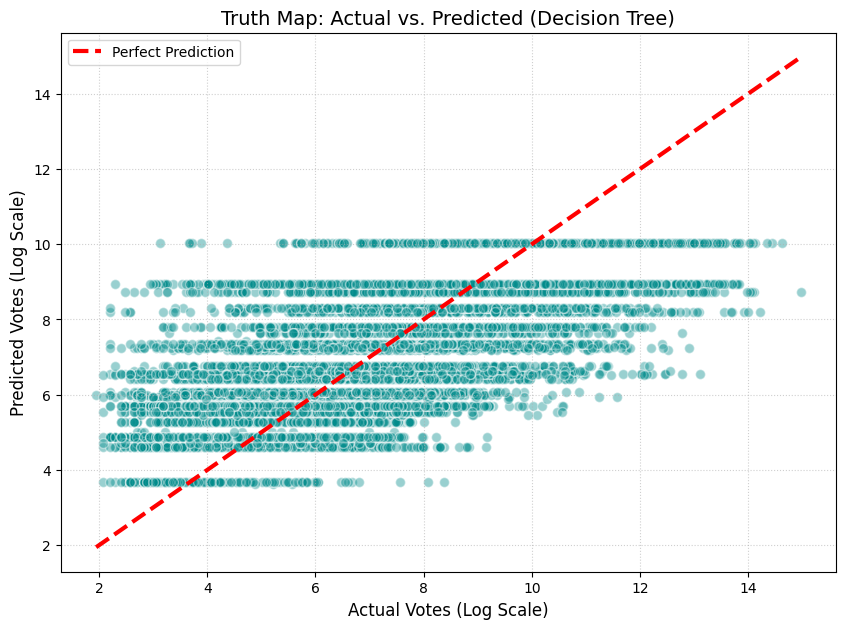

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions from our winning model
preds_dt_log = model_dt_log.predict(X_test)

# 2. Create the plot
plt.figure(figsize=(10, 7))

# Scatter plot: Actual vs. Predicted
# 'alpha' makes the dots transparent so we can see where they overlap
plt.scatter(y_test_log, preds_dt_log, alpha=0.4, color='darkcyan', edgecolors='white', s=50)

# The "Perfect Prediction" Line (y = x)
line_coords = [y_test_log.min(), y_test_log.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=3, label='Perfect Prediction')

# Formatting
plt.title('Truth Map: Actual vs. Predicted (Decision Tree)', fontsize=14)
plt.xlabel('Actual Votes (Log Scale)', fontsize=12)
plt.ylabel('Predicted Votes (Log Scale)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

1. Mean Absolute Error (MAE)

This measures the average distance between the dots and the red line.$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$Your Result (Log): ~1.42Meaning: On average, the machine is off by 1.42 units on the log scale.

2. R-Squared ($R^2$)

This tells us what percentage of the "spread" of the dots is explained by our diagonal red line.$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Our Result: 0.432Meaning: 43.2% of the variation in movie popularity is successfully captured by our features (Stars, Year, Rating, etc.).

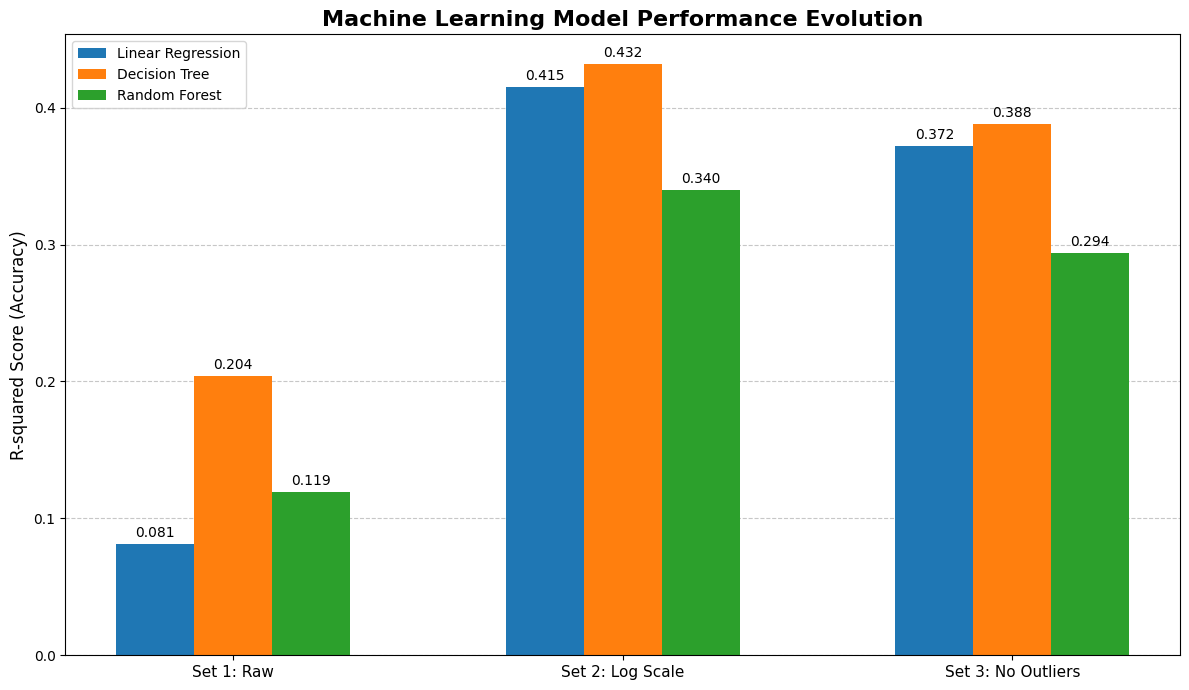

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data from our results table
labels = ['Set 1: Raw', 'Set 2: Log Scale', 'Set 3: No Outliers']
lr_scores = [0.081, 0.415, 0.372]
dt_scores = [0.204, 0.432, 0.388]
rf_scores = [0.119, 0.340, 0.294]

x = np.arange(len(labels))  # The label locations
width = 0.2  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

# 2. Create the grouped bars
rects1 = ax.bar(x - width, lr_scores, width, label='Linear Regression', color='#1f77b4')
rects2 = ax.bar(x, dt_scores, width, label='Decision Tree', color='#ff7f0e')
rects3 = ax.bar(x + width, rf_scores, width, label='Random Forest', color='#2ca02c')

# 3. Add text for labels, title and custom x-axis tick labels
ax.set_ylabel('R-squared Score (Accuracy)', fontsize=12)
ax.set_title('Machine Learning Model Performance Evolution', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend()

# 4. Add a grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Put grid behind bars

# 5. Function to add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

## Q5: How does the timing of a movie’s release (month or season) influence its box office performance and audience engagement?

### Data Cleaning

In [1]:
import ast
import re
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


if 'df_merged' not in globals():
    df_csv = pd.read_csv('final_dataset.csv').rename(columns={'id': 'tconst'})
    df_ratings = pd.read_csv('title.ratings.tsv', sep='\t')
    df_merged = pd.merge(df_csv, df_ratings, on='tconst', how='left')


EXCHANGE_RATES = {
    'USD': 1.0, 'EUR': 1.08, 'GBP': 1.27, 'CAD': 0.74, 'AUD': 0.65,
    'JPY': 0.0067, 'INR': 0.012, 'KRW': 0.00073, 'CNY': 0.14, 'HKD': 0.128,
    'SGD': 0.75, 'NZD': 0.61, 'BRL': 0.20, 'MXN': 0.058, 'RUB': 0.011,
    'TRY': 0.031, 'PLN': 0.25, 'CHF': 1.13, 'ZAR': 0.055, 'DEM': 0.55,
    'FRF': 0.165, 'ITL': 0.00056, 'NLG': 0.49, 'BEF': 0.027, 'ESP': 0.0065,
    'SEK': 0.096, 'NOK': 0.093, 'DKK': 0.145, 'ILS': 0.27, 'TWD': 0.031,
}

SYMBOL_MAP = [
    ('CA$', 'CAD'), ('A$', 'AUD'), ('HK$', 'HKD'), ('NZ$', 'NZD'), ('MX$', 'MXN'),
    ('NT$', 'TWD'), ('R$', 'BRL'), ('SGD', 'SGD'), ('SEK', 'SEK'), ('NOK', 'NOK'),
    ('DKK', 'DKK'), ('DEM', 'DEM'), ('FRF', 'FRF'), ('ITL', 'ITL'), ('BEF', 'BEF'),
    ('ESP', 'ESP'), ('NLG', 'NLG'), ('RUB', 'RUB'), ('RUR', 'RUB'), ('TRY', 'TRY'),
    ('TRL', 'TRY'), ('PLN', 'PLN'), ('CHF', 'CHF'), ('ZAR', 'ZAR'), ('ILS', 'ILS'),
    ('$', 'USD'),
]


def detect_currency(text):
    for pattern, code in SYMBOL_MAP:
        if pattern in text:
            return code
    return 'USD'


def parse_money(value):
    if pd.isna(value) or str(value).strip() == '':
        return np.nan
    text = str(value).strip()
    rate = EXCHANGE_RATES.get(detect_currency(text), 1.0)
    digits = re.sub(r'[^\d.]', '', text)
    if not digits:
        return np.nan
    try:
        return round(float(digits) * rate, 2)
    except ValueError:
        return np.nan


def parse_list_col(value):
    if pd.isna(value) or str(value).strip() == '':
        return []
    try:
        result = ast.literal_eval(str(value))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return re.findall(r"'([^']+)'", str(value))


def month_to_season(month):
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    }
    return season_map.get(month, 'Unknown')


def first_item(items):
    return items[0] if items else 'Unknown'


q5_raw = df_merged.copy()
q5_raw['release_date_dt'] = pd.to_datetime(q5_raw['release_date'], errors='coerce')
q5_raw['year'] = q5_raw['release_date_dt'].dt.year
q5_raw['month'] = q5_raw['release_date_dt'].dt.month
q5_raw['season'] = q5_raw['month'].apply(month_to_season)
q5_raw['runtime'] = pd.to_numeric(q5_raw['duration'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
q5_raw['stars_list'] = q5_raw['stars'].apply(parse_list_col)
q5_raw['directors_list'] = q5_raw['directors'].apply(parse_list_col)
q5_raw['writers_list'] = q5_raw['writers'].apply(parse_list_col)
q5_raw['genres_list'] = q5_raw['genres'].apply(parse_list_col)
q5_raw['star_count'] = q5_raw['stars_list'].apply(len)
q5_raw['director_count'] = q5_raw['directors_list'].apply(len)
q5_raw['writer_count'] = q5_raw['writers_list'].apply(len)
q5_raw['primary_genre'] = q5_raw['genres_list'].apply(first_item)
q5_raw['budget_num'] = q5_raw['budget'].apply(parse_money)
q5_raw['opening_weekend_num'] = q5_raw['opening_weekend_gross'].apply(parse_money)
q5_raw['gross_worldwide_num'] = q5_raw['gross_worldwide'].apply(parse_money)
q5_raw['numVotes'] = pd.to_numeric(q5_raw['numVotes'], errors='coerce')

print('Q5 base dataset prepared.')
print(q5_raw[['year', 'month', 'season', 'runtime', 'star_count', 'budget_num', 'gross_worldwide_num', 'numVotes']].head())
print('\nMissing values in the two Q5 targets:')
print(q5_raw[['gross_worldwide_num', 'numVotes']].isna().sum())

Q5 base dataset prepared.
   year  month  season  runtime  star_count  budget_num  gross_worldwide_num  \
0  1985      3  Spring      1.0          10         NaN                  NaN   
1  1956      9  Autumn      1.0          10         NaN                  NaN   
2  1960     11  Autumn      1.0          10         NaN                  NaN   
3  2019      3  Spring      1.0          10    150000.0              14518.0   
4  2024      2  Winter      1.0           5         NaN           44354825.0   

   numVotes  
0     388.0  
1      18.0  
2     560.0  
3     194.0  
4   10678.0  

Missing values in the two Q5 targets:
gross_worldwide_num    42527
numVotes                3976
dtype: int64


For Q5, the key cleaning task is to turn release timing and box-office fields into machine-readable variables. I parse `release_date` into `year`, `month`, and `season`, convert `duration` into numeric runtime, count the number of listed stars, directors, and writers, and turn formatted money strings such as `$50,000,000` or `CA$450,000` into comparable USD values.

I keep the cleaning conservative. Rows are not dropped immediately from the full table; instead, I create a clean base dataset first and only drop rows later when a specific target variable is required. That lets us model worldwide gross and audience votes from the same prepared table while preserving as many movies as possible.

### Data Curation

In [2]:
q5_feature_cols = [
    'year', 'month', 'season', 'runtime', 'budget_num',
    'star_count', 'director_count', 'writer_count', 'primary_genre'
 ]

q5_target_cols = {
    'Worldwide Gross': 'gross_worldwide_num',
    'Audience Votes': 'numVotes',
}

q5_model_df = q5_raw[q5_feature_cols + list(q5_target_cols.values())].copy()
q5_model_df['season'] = q5_model_df['season'].fillna('Unknown')
q5_model_df['primary_genre'] = q5_model_df['primary_genre'].fillna('Unknown')

print('Q5 modeling columns selected.')
print(q5_model_df.head())
print('\nRows available before target-specific filtering:', len(q5_model_df))

Q5 modeling columns selected.
   year  month  season  runtime  budget_num  star_count  director_count  \
0  1985      3  Spring      1.0         NaN          10               1   
1  1956      9  Autumn      1.0         NaN          10               1   
2  1960     11  Autumn      1.0         NaN          10               1   
3  2019      3  Spring      1.0    150000.0          10               1   
4  2024      2  Winter      1.0         NaN           5               1   

   writer_count primary_genre  gross_worldwide_num  numVotes  
0             2         Drama                  NaN     388.0  
1             3         Drama                  NaN      18.0  
2             2         Drama                  NaN     560.0  
3             2   Documentary              14518.0     194.0  
4             1         Anime           44354825.0   10678.0  

Rows available before target-specific filtering: 63249


The curation step keeps the analysis aligned with the question. I use timing variables (`month` and `season`) as the main variables of interest, then add control variables that can also influence performance: `year`, `runtime`, `budget_num`, the counts of stars, directors, and writers, and the movie’s primary genre.

I deliberately do not use post-release outcomes as predictors. For example, `gross_worldwide_num` is only a target in the box-office model, and `numVotes` is only a target in the audience-engagement model. This avoids target leakage and keeps the interpretation focused on whether release timing adds predictive value beyond basic movie attributes.

### Removing Redundant Features

In [3]:
q5_redundant_features = ['month']

# We keep 'season' and drop raw 'month' before modeling to avoid duplicating the same timing signal.
q5_model_df = q5_model_df.drop(columns=q5_redundant_features)

print('Dropped redundant Q5 predictors:', q5_redundant_features)
print('Remaining Q5 predictors:', q5_model_df.columns.tolist())

Dropped redundant Q5 predictors: ['month']
Remaining Q5 predictors: ['year', 'season', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count', 'primary_genre', 'gross_worldwide_num', 'numVotes']


For Q5 I remove redundancy in a simple, explainable way. Because `month` and `season` encode the same timing idea at different granularities, I keep `season` as the cleaner, more interpretable version and drop `month` from the final models.

I do not do aggressive correlation pruning here because the feature set is already compact and each variable has a clear interpretation. That makes the later feature-importance discussion easier to explain.

### Data Transformation: Creating X Input and Y Output Variables

In [4]:
q5_datasets = {}

q5_predictor_cols = [
    'year', 'season', 'runtime', 'budget_num',
    'star_count', 'director_count', 'writer_count', 'primary_genre',
]

for target_name, target_col in q5_target_cols.items():
    q5_subset = q5_model_df.dropna(subset=[target_col]).copy()
    q5_subset[q5_predictor_cols] = q5_subset[q5_predictor_cols].copy()
    q5_subset[['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']] = (
        q5_subset[['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']]
        .apply(pd.to_numeric, errors='coerce')
    )
    q5_subset[q5_predictor_cols] = q5_subset[q5_predictor_cols].fillna({
        'season': 'Unknown',
        'primary_genre': 'Unknown',
    })
    numeric_cols = ['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']
    q5_subset[numeric_cols] = q5_subset[numeric_cols].fillna(q5_subset[numeric_cols].median())

    X_q5 = pd.get_dummies(q5_subset[q5_predictor_cols], columns=['season', 'primary_genre'], drop_first=False)
    y_q5 = np.log1p(q5_subset[target_col])

    q5_datasets[target_name] = {
        'data': q5_subset,
        'X': X_q5,
        'y': y_q5,
    }

for name, bundle in q5_datasets.items():
    print(f"{name}: X shape = {bundle['X'].shape}, y shape = {bundle['y'].shape}")

Worldwide Gross: X shape = (20722, 188), y shape = (20722,)
Audience Votes: X shape = (59273, 189), y shape = (59273,)


The final transformation produces two target-specific datasets from the same cleaned movie table. For each target, the predictor matrix contains timing, budget, crew-size, and genre information, and the target is transformed with `log1p(...)` to reduce the influence of extreme blockbuster values.

This mirrors the lesson from Q4: movie outcomes such as gross revenue and total votes are highly right-skewed. Modeling them on the log scale makes the regression problem more stable and the error metrics easier to compare across models.

### Data Splitting (Train-Test set and test set)

In [5]:
from sklearn.model_selection import train_test_split

q5_splits = {}

for target_name, bundle in q5_datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        bundle['X'], bundle['y'], test_size=0.2, random_state=42
    )
    q5_splits[target_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
    }
    print(f"{target_name}: train = {len(X_train)}, test = {len(X_test)}")

Worldwide Gross: train = 16577, test = 4145
Audience Votes: train = 47418, test = 11855


I use a simple 80/20 train-test split with `random_state=42` so the results are reproducible. Because this is a regression task with two different log-transformed targets, a plain random split is more appropriate here than the rating-style bin stratification that appeared earlier in the notebook.

The same split logic is applied separately to the worldwide-gross target and the audience-votes target. That keeps each experiment self-contained and makes the performance tables easier to read.

#### Save splits in form of CSV files

In [6]:
for target_name, split in q5_splits.items():
    safe_name = target_name.lower().replace(' ', '_')
    split['X_train'].to_csv(f'outputs/q5_{safe_name}_X_train.csv', index=False)
    split['X_test'].to_csv(f'outputs/q5_{safe_name}_X_test.csv', index=False)
    split['y_train'].to_csv(f'outputs/q5_{safe_name}_y_train.csv', index=False)
    split['y_test'].to_csv(f'outputs/q5_{safe_name}_y_test.csv', index=False)
    print(f"Saved Q5 splits for {target_name} in outputs/.")

Saved Q5 splits for Worldwide Gross in outputs/.
Saved Q5 splits for Audience Votes in outputs/.


The saved CSV files make the workflow easy to inspect outside the notebook and consistent with the rest of the project. I save one train and one test split per target in the `outputs/` folder so the box-office and engagement experiments remain separate.

### Selecting and training machine learning models

As in Q4, I compare three models with different strengths: Linear Regression for a clean baseline, Decision Tree Regressor for interpretable non-linear rules, and Random Forest Regressor for a stronger ensemble baseline.

In [9]:
q5_model_factories = {
    'Linear Regression': lambda: LinearRegression(),
    'Decision Tree': lambda: DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest': lambda: RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

q5_trained_models = {}
q5_results = []

for target_name, split in q5_splits.items():
    q5_trained_models[target_name] = {}
    for model_name, model_factory in q5_model_factories.items():
        model = model_factory()
        model.fit(split['X_train'], split['y_train'])
        preds = model.predict(split['X_test'])
        q5_trained_models[target_name][model_name] = model
        q5_results.append({
            'Target': target_name,
            'Model': model_name,
            'MAE (Log)': mean_absolute_error(split['y_test'], preds),
            'RMSE (Log)': np.sqrt(mean_squared_error(split['y_test'], preds)),
            'R2 Score': r2_score(split['y_test'], preds),
        })

q5_results_df = pd.DataFrame(q5_results).sort_values(['Target', 'R2 Score'], ascending=[True, False])
print(q5_results_df)

            Target              Model  MAE (Log)  RMSE (Log)  R2 Score
5   Audience Votes      Random Forest   1.171975    1.498689  0.606372
4   Audience Votes      Decision Tree   1.232361    1.559359  0.573857
3   Audience Votes  Linear Regression   1.273512    1.607041  0.547398
1  Worldwide Gross      Decision Tree   1.876221    2.416732  0.483669
2  Worldwide Gross      Random Forest   1.833629    2.442508  0.472596
0  Worldwide Gross  Linear Regression   2.249392    2.814536  0.299699


The model comparison is intentionally simple and explainable. Linear Regression tests whether timing and movie attributes behave roughly linearly, the Decision Tree checks whether timing works through threshold-style rules such as seasonal release windows, and the Random Forest provides a stronger non-linear benchmark without becoming too opaque.

I cap the single Decision Tree at `max_depth=6` to keep it readable and reduce overfitting, while the Random Forest uses 200 trees to stabilize the predictions.

### Evaluate model performance

Best Q5 model per target:
            Target          Model  MAE (Log)  RMSE (Log)  R2 Score
5   Audience Votes  Random Forest   1.171975    1.498689  0.606372
1  Worldwide Gross  Decision Tree   1.876221    2.416732  0.483669


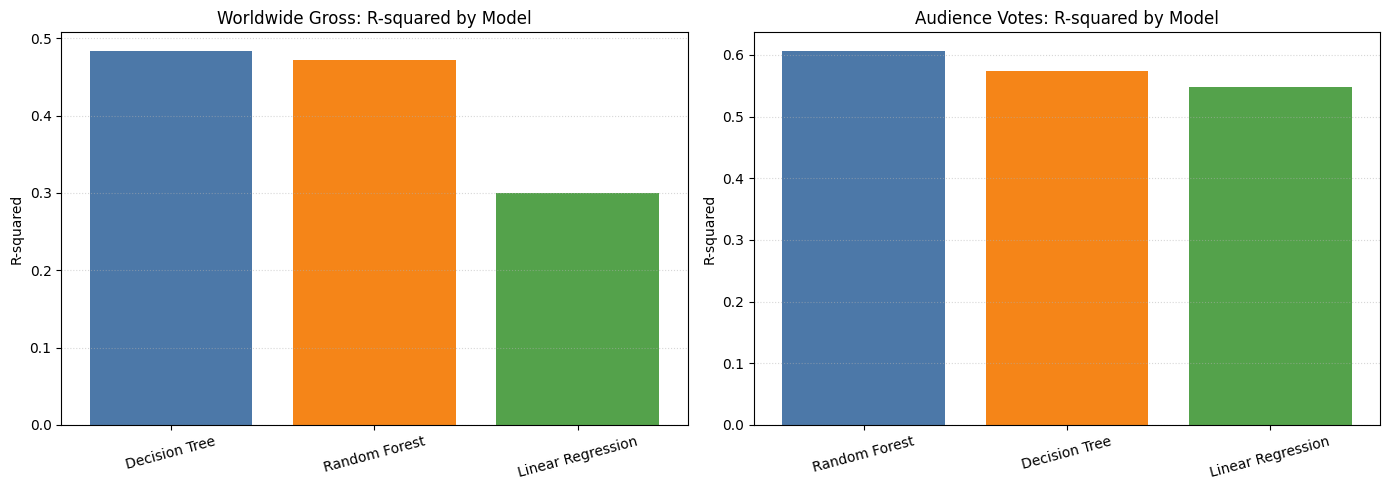


Top predictors for Audience Votes using Random Forest:
budget_num                   0.447464
year                         0.262542
writer_count                 0.029311
star_count                   0.019354
runtime                      0.017566
primary_genre_Documentary    0.015366
primary_genre_Drama          0.012372
season_Autumn                0.012012
dtype: float64

Top predictors for Worldwide Gross using Decision Tree:
budget_num                   0.802844
year                         0.093625
primary_genre_Documentary    0.052730
runtime                      0.016495
primary_genre_Drama          0.015645
director_count               0.004493
star_count                   0.003248
primary_genre_Comedy         0.002624
dtype: float64


In [10]:
import matplotlib.pyplot as plt

q5_best_models = q5_results_df.loc[q5_results_df.groupby('Target')['R2 Score'].idxmax()].copy()
print('Best Q5 model per target:')
print(q5_best_models)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target_name in zip(axes, q5_target_cols.keys()):
    target_rows = q5_results_df[q5_results_df['Target'] == target_name]
    ax.bar(target_rows['Model'], target_rows['R2 Score'], color=['#4c78a8', '#f58518', '#54a24b'])
    ax.set_title(f'{target_name}: R-squared by Model')
    ax.set_ylabel('R-squared')
    ax.set_ylim(bottom=min(0, target_rows['R2 Score'].min() - 0.05))
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

q5_feature_summaries = {}

for _, row in q5_best_models.iterrows():
    target_name = row['Target']
    model_name = row['Model']
    model = q5_trained_models[target_name][model_name]
    feature_names = q5_splits[target_name]['X_train'].columns

    if hasattr(model, 'feature_importances_'):
        importance = pd.Series(model.feature_importances_, index=feature_names)
    else:
        importance = pd.Series(np.abs(model.coef_), index=feature_names)

    q5_feature_summaries[target_name] = importance.sort_values(ascending=False).head(8)
    print(f"\nTop predictors for {target_name} using {model_name}:")
    print(q5_feature_summaries[target_name])

I evaluate the models with `MAE`, `RMSE`, and `R²` on the log-transformed targets. The key number for model comparison is `R²`, because it shows how much of the variation in box-office performance or audience engagement is explained by the selected predictors.

The evaluation also includes a small feature-importance summary for the best model on each target. That matters for the actual research question: even if a model predicts reasonably well, we still need to see whether release timing remains one of the meaningful predictors once budget, runtime, cast size, and genre are included.

## Q6: Can movies be classified into successful vs less successful categories based on their attributes?

### Data Cleaning

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

if 'q5_raw' not in globals():
    raise RuntimeError('Run the Q5 data-preparation cell first so the shared movie table exists.')

q6_raw = q5_raw.copy()
q6_raw['rating_num'] = pd.to_numeric(q6_raw['averageRating'], errors='coerce')
q6_raw['roi'] = np.where(
    q6_raw['budget_num'] > 0,
    (q6_raw['gross_worldwide_num'] - q6_raw['budget_num']) / q6_raw['budget_num'],
    np.nan,
)

q6_base = q6_raw.dropna(subset=['rating_num', 'numVotes', 'budget_num', 'gross_worldwide_num']).copy()

rating_cutoff = q6_base['rating_num'].median()
votes_cutoff = q6_base['numVotes'].median()

q6_base['success_score'] = (
    (q6_base['rating_num'] >= rating_cutoff).astype(int)
    + (q6_base['numVotes'] >= votes_cutoff).astype(int)
    + (q6_base['roi'] > 0).astype(int)
)
q6_base['success_label'] = (q6_base['success_score'] >= 2).astype(int)

print('Q6 classification base table prepared.')
print(f'Rows available: {len(q6_base)}')
print(f'Rating median: {rating_cutoff:.2f}')
print(f'Votes median: {votes_cutoff:,.0f}')
print(q6_base['success_label'].value_counts().rename(index={0: 'Less Successful', 1: 'Successful'}))

Q6 classification base table prepared.
Rows available: 10413
Rating median: 6.50
Votes median: 26,084
success_label
Successful         5281
Less Successful    5132
Name: count, dtype: int64


Q6 needs a binary target before any classification can happen, so the first task is to define “successful” in a transparent way. I create a `success_score` from three outcome dimensions: rating quality, audience reach, and financial return. A movie is labeled `successful` if it clears at least two of these three thresholds: rating above the median, votes above the median, and positive ROI.

This is stricter than using only one outcome and more balanced than using box office alone. It also keeps the label explainable, because success in this project is meant to combine critical reception, audience attention, and commercial performance.

### Data Curation

In [12]:
q6_feature_cols = [
    'year', 'season', 'runtime', 'budget_num', 'star_count',
    'director_count', 'writer_count', 'primary_genre', 'mpa',
]

q6_model_df = q6_base[q6_feature_cols + ['success_label']].copy()
q6_model_df['season'] = q6_model_df['season'].fillna('Unknown')
q6_model_df['primary_genre'] = q6_model_df['primary_genre'].fillna('Unknown')
q6_model_df['mpa'] = q6_model_df['mpa'].fillna('Unknown')

print('Q6 predictors and target selected.')
print(q6_model_df.head())

Q6 predictors and target selected.
    year  season  runtime  budget_num  star_count  director_count  \
3   2019  Spring      1.0    150000.0          10               1   
9   1988  Autumn      1.0  10000000.0          10               1   
11  1994  Autumn      2.0  60000000.0          10               1   
12  2006  Autumn      1.0    900000.0          10               1   
16  2005  Winter      1.0  26000000.0          10               1   

    writer_count    primary_genre      mpa  success_label  
3              2      Documentary  Unknown              0  
9              1            Drama       PG              0  
11             1     Dark Fantasy        R              1  
12             2            Drama  Unrated              0  
16             1  Romantic Comedy    PG-13              1  


The Q6 predictors are limited to movie attributes that are available before or independent of the success label: release timing, runtime, budget, crew-size signals, genre, and age rating. I do not include `averageRating`, `numVotes`, `gross_worldwide_num`, or `roi` as predictors, because those variables were used to construct the label itself.

That separation is important. It means the classifier must learn success from the movie’s attributes rather than from the answer key.

### Removing Redundant Features

In [13]:
q6_redundant_features = []

# The Q6 feature set is already compact, so we only keep a note that leakage variables were excluded earlier.
print('No additional Q6 columns were dropped here because leakage variables were excluded during curation.')

No additional Q6 columns were dropped here because leakage variables were excluded during curation.


Unlike Q5, Q6 does not need much extra pruning because the main source of redundancy was already removed by excluding leakage variables. The remaining columns each serve a different explanatory purpose: timing, cost, crew scale, genre, and rating certification.

### Data Transformation: Creating X Input and Y Output Variables

In [14]:
q6_numeric_cols = ['year', 'runtime', 'budget_num', 'star_count', 'director_count', 'writer_count']
q6_model_df[q6_numeric_cols] = q6_model_df[q6_numeric_cols].apply(pd.to_numeric, errors='coerce')
q6_model_df[q6_numeric_cols] = q6_model_df[q6_numeric_cols].fillna(q6_model_df[q6_numeric_cols].median())

X_q6 = pd.get_dummies(
    q6_model_df[q6_feature_cols],
    columns=['season', 'primary_genre', 'mpa'],
    drop_first=False,
 )
y_q6 = q6_model_df['success_label']

print('Q6 classification matrix ready.')
print('X shape:', X_q6.shape)
print('y distribution:')
print(y_q6.value_counts(normalize=True).rename(index={0: 'Less Successful', 1: 'Successful'}))

Q6 classification matrix ready.
X shape: (10413, 202)
y distribution:
success_label
Successful         0.507155
Less Successful    0.492845
Name: proportion, dtype: float64


The Q6 transformation step converts the mixed movie attributes into a fully numeric feature matrix. Numeric variables are median-imputed, while categorical variables such as season, genre, and MPA rating are one-hot encoded so that all three classifiers can use them directly.

The output variable is the binary `success_label`, where `1` means successful and `0` means less successful.

### Data Splitting (Train-Test set and test set)

In [15]:
X_train_q6, X_test_q6, y_train_q6, y_test_q6 = train_test_split(
    X_q6,
    y_q6,
    test_size=0.2,
    random_state=42,
    stratify=y_q6,
 )

print(f'Train: {len(X_train_q6)} | Test: {len(X_test_q6)}')

Train: 8330 | Test: 2083


For classification I use a stratified 80/20 split so that the share of successful and less successful movies stays similar in both training and test data. That matters more here than in Q5 because class imbalance can distort classification metrics if one class is over- or under-represented after the split.

#### Save splits in form of CSV files

In [16]:
X_train_q6.to_csv('outputs/q6_X_train.csv', index=False)
X_test_q6.to_csv('outputs/q6_X_test.csv', index=False)
y_train_q6.to_csv('outputs/q6_y_train.csv', index=False)
y_test_q6.to_csv('outputs/q6_y_test.csv', index=False)

print('Saved Q6 train/test splits in outputs/.')

Saved Q6 train/test splits in outputs/.


The split files are saved separately for Q6 so the classification task can be rerun or reviewed independently from the Q5 regressions.

### Selecting and training machine learning models

For Q6 I compare Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. This gives one linear baseline and two non-linear tree-based approaches, again matching the spirit of Q4.

In [17]:
q6_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

q6_trained_models = {}
q6_results = []

for model_name, model in q6_models.items():
    model.fit(X_train_q6, y_train_q6)
    preds = model.predict(X_test_q6)
    probs = model.predict_proba(X_test_q6)[:, 1] if hasattr(model, 'predict_proba') else None
    q6_trained_models[model_name] = model
    q6_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_q6, preds),
        'Precision': precision_score(y_test_q6, preds, zero_division=0),
        'Recall': recall_score(y_test_q6, preds, zero_division=0),
        'F1 Score': f1_score(y_test_q6, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_q6, probs) if probs is not None else np.nan,
    })

q6_results_df = pd.DataFrame(q6_results).sort_values('F1 Score', ascending=False)
print(q6_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.700432   0.706897  0.698864  0.702857  0.766544
0  Logistic Regression  0.510322   0.508679  0.999053  0.674121  0.331797
1        Decision Tree  0.663946   0.692641  0.606061  0.646465  0.723093


Logistic Regression gives a clean linear baseline for the success label, while the Decision Tree and Random Forest let us test whether success is driven by threshold effects and non-linear interactions between timing, budget, and movie attributes.

As in Q5, the single tree is depth-limited for readability and the forest is used as the stronger ensemble benchmark.

### Evaluate model performance

Best Q6 model:
           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2  Random Forest  0.700432   0.706897  0.698864  0.702857  0.766544


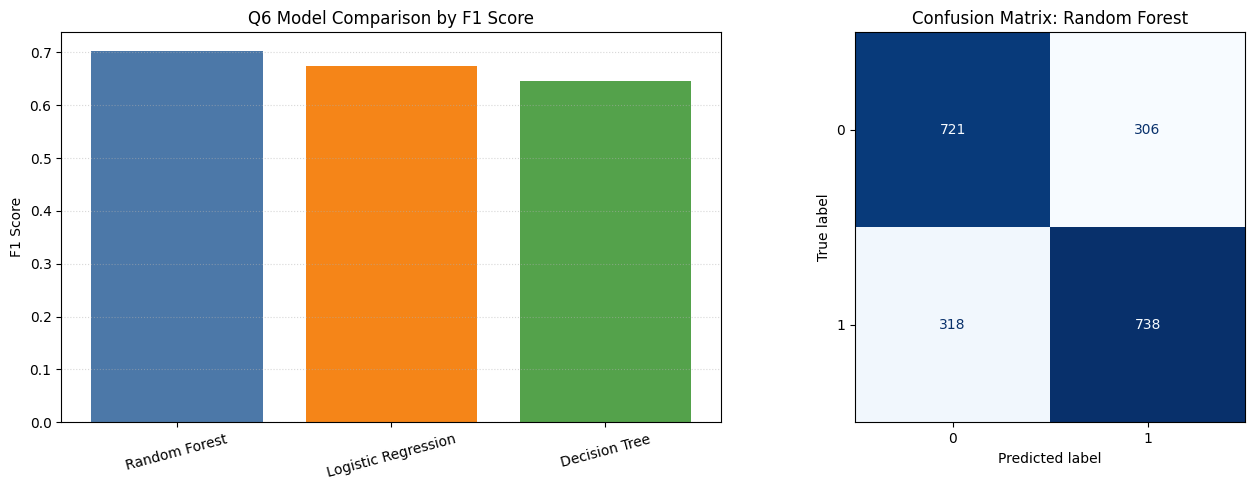


Top Q6 predictors:
budget_num              0.246043
year                    0.194611
writer_count            0.047563
runtime                 0.028049
primary_genre_Drama     0.027247
primary_genre_Comedy    0.023508
primary_genre_Action    0.017401
season_Autumn           0.017097
season_Winter           0.016396
season_Summer           0.016000
dtype: float64


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

q6_best_model_name = q6_results_df.iloc[0]['Model']
q6_best_model = q6_trained_models[q6_best_model_name]
q6_best_preds = q6_best_model.predict(X_test_q6)

print('Best Q6 model:')
print(q6_results_df.head(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(q6_results_df['Model'], q6_results_df['F1 Score'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[0].set_title('Q6 Model Comparison by F1 Score')
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

ConfusionMatrixDisplay.from_predictions(
    y_test_q6, q6_best_preds, ax=axes[1], cmap='Blues', colorbar=False
 )
axes[1].set_title(f'Confusion Matrix: {q6_best_model_name}')

plt.tight_layout()
plt.show()

if hasattr(q6_best_model, 'feature_importances_'):
    q6_importance = pd.Series(q6_best_model.feature_importances_, index=X_train_q6.columns)
else:
    q6_importance = pd.Series(np.abs(q6_best_model.coef_[0]), index=X_train_q6.columns)

print('\nTop Q6 predictors:')
print(q6_importance.sort_values(ascending=False).head(10))

For Q6, the most informative metric is the F1 score because it balances precision and recall. A classifier can look good on accuracy alone if one class is easier to guess, so I also report precision, recall, and ROC-AUC.

The confusion matrix is included because it shows the type of mistakes the best model makes: whether it is missing too many genuinely successful movies or incorrectly promoting too many less successful ones. That makes the final interpretation more useful for the project discussion.

# DATA VISUALIZATION OF PREDICTIONS RESULTS

The charts above summarize the model comparison directly inside the notebook. Q5 uses side-by-side R-squared plots for each regression target, and Q6 combines an F1 comparison plot with a confusion matrix for the winning classifier.

# MODEL OUTPUTS AND COMPARISON

The notebook now compares models by the metric that best fits each question: `R²` for the Q5 regressions and `F1` for the Q6 classifier. The best model in each section is then inspected with feature importance so the final discussion can explain not only which model performed best, but also which attributes were most influential.